## Baseline Experiments

This notebook focuses on testing different experiments on the baseline. Baseline in this project serves similiarly as self-grafting operator baseline in Grafting paper, however we use small defined set of operators instead of randomly initialized operator weights.

setup

In [1]:
from math import ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.capture import ActivationPairs, collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig, OperatorConfig, RecoveryConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.language_model import evaluate_language_model
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import GatedMLPReplacement, fit_operator, fit_ridge_linear
from mlp_replacement.recovery import cache_teacher_logits, distillation_loss
from mlp_replacement.surgery import count_parameters, temporary_replacement

### Single-block Experiments

In [4]:
SEED = 21
TARGET_LAYER = 11

MAX_CALIBRATION_BATCHES = 48
CALIBRATION_BUDGETS = [8, 16, 32, 48]

SWIGLU_WIDTH_RATIOS = [0.25, 0.50, 0.75, 0.90]
RECOVERY_UPDATE_BUDGETS = [0, 8, 16, 32, 64]

LINEAR_RIDGE = 1e-4

In [5]:
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)
data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=MAX_CALIBRATION_BATCHES,
    num_operator_validation_batches=24,
    num_recovery_batches=max(RECOVERY_UPDATE_BUDGETS),
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

In [7]:
training_config = OperatorConfig(
    kind='bottleneck_mlp',
    bottleneck_ratio=0.5,
    activation='silu',
    bias=False,
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

In [8]:
recovery_config = RecoveryConfig(
    enabled=True,
    epochs=1,
    learning_rate=1e-5,
    weight_decay=0.0,
    temperature=1.0,
    cache_dtype='float16',
    early_stopping_patience=None,
)

In [9]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
block = get_mlp_block(model, TARGET_LAYER)

/home/sgulas/miniconda3/envs/mlp-replacement/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 4511.61it/s]


In [10]:
loaders = build_data_loaders(
    tokenizer,
    data_config,
    include_recovery=True,
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


In [11]:
capture_kwargs = {
    'device': device,
    'storage_device': 'cpu',
    'storage_dtype': torch.float32,
}
training_pool = collect_module_io(
    model,
    block.path,
    loaders.calibration,
    MAX_CALIBRATION_BATCHES,
    **capture_kwargs,
)
validation_pairs = collect_module_io(
    model,
    block.path,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)

In [12]:
hidden_size = training_pool.hidden_size
original_intermediate_width = int(block.module.up_proj.out_features)
original_parameters = count_parameters(block.module)
tokens_per_batch = data_config.batch_size * data_config.sequence_length

In [13]:
baseline_lm = evaluate_language_model(
    model,
    loaders.model_validation,
    device,
    data_config.num_model_validation_batches,
)

In [14]:
def calibration_prefix(num_batches):
    token_count = num_batches * tokens_per_batch
    return ActivationPairs(
        inputs=training_pool.inputs[:token_count],
        targets=training_pool.targets[:token_count],
    )

In [15]:
def local_row(name, module, pairs, fit=None):
    module = module.to(device)
    metrics = evaluate_operator(
        module,
        validation_pairs,
        device,
        training_config.batch_size,
    )
    epochs = len(fit.history) if fit is not None else 0
    return {
        'operator': name,
        'calibration_tokens': pairs.num_tokens,
        'parameters': count_parameters(module),
        'local_mse': metrics.mse,
        'local_relative_mse': metrics.relative_mse,
        'local_cosine': metrics.cosine_similarity,
        'best_epoch': fit.best_epoch if fit is not None else 0,
        'optimizer_steps': (
            epochs * ceil(pairs.num_tokens / training_config.batch_size)
        ),
    }

In [16]:
def model_metrics(module):
    module = module.to(device)
    with temporary_replacement(model, TARGET_LAYER, module):
        return evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )

### Experiments

#### Calibration data scaling

,operator,calibration_tokens,parameters,local_mse,local_relative_mse,local_cosine,best_epoch,optimizer_steps,loss,perplexity,delta_loss,delta_perplexity,calibration_batches
0,linear,2048,4194304,23.840908,15.282247,0.131956,0,0,4.441403,84.894001,1.771430,70.454416,8
1,affine,2048,4196352,25.840072,16.563730,0.127856,0,0,4.593343,98.824280,1.923370,84.384694,8
2,swiglu_0.50,2048,25165824,1.304988,0.836509,0.411241,64,64,2.730558,15.341441,0.060584,0.901855,8
3,linear,4096,4194304,2.103616,1.348438,0.432234,0,0,2.787512,16.240557,0.117538,1.800972,16
4,affine,4096,4196352,2.105342,1.349544,0.441179,0,0,2.786200,16.219277,0.116227,1.779691,16
5,swiglu_0.50,4096,25165824,1.154697,0.740172,0.510903,64,128,2.722960,15.225325,0.052987,0.785739,16
6,linear,8192,4194304,1.269337,0.813657,0.553032,0,0,2.738213,15.459340,0.068240,1.019754,32
7,affine,8192,4196352,1.269610,0.813832,0.563841,0,0,2.738249,15.459895,0.068276,1.020309,32
8,swiglu_0.50,8192,25165824,1.037086,0.664782,0.582659,57,240,2.720240,15.183963,0.050266,0.744377,32
9,linear,12288,4194304,1.092005,0.699985,0.594356,0,0,2.725901,15.270173,0.055928,0.830587,48


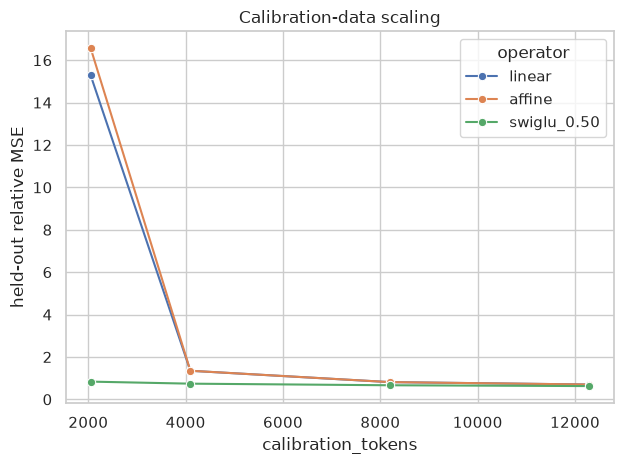

In [17]:
budget_rows = []
history_rows = []
fixed_width = round(0.5 * original_intermediate_width)

for num_batches in CALIBRATION_BUDGETS:
    pairs = calibration_prefix(num_batches)
    linear = fit_ridge_linear(
        pairs, ridge=LINEAR_RIDGE, bias=False, device=device
    )
    affine = fit_ridge_linear(
        pairs, ridge=LINEAR_RIDGE, bias=True, device=device
    )
    torch.manual_seed(SEED)
    swiglu_fit = fit_operator(
        GatedMLPReplacement(hidden_size, fixed_width, bias=False),
        pairs,
        validation_pairs,
        training_config,
        device,
    )
    steps_per_epoch = ceil(
        pairs.num_tokens / training_config.batch_size
    )
    for epoch in swiglu_fit.history:
        history_rows.append({
            'calibration_batches': num_batches,
            'calibration_tokens': pairs.num_tokens,
            'epoch': epoch.epoch,
            'optimizer_steps': epoch.epoch * steps_per_epoch,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

    for name, module, fit in [
        ('linear', linear, None),
        ('affine', affine, None),
        ('swiglu_0.50', swiglu_fit.module, swiglu_fit),
    ]:
        row = local_row(name, module, pairs, fit)
        integrated = model_metrics(module)
        row.update({
            'loss': integrated.loss,
            'perplexity': integrated.perplexity,
            'delta_loss': integrated.loss - baseline_lm.loss,
            'delta_perplexity': (
                integrated.perplexity - baseline_lm.perplexity
            ),
        })
        row['calibration_batches'] = num_batches
        budget_rows.append(row)

budget_df = pd.DataFrame(budget_rows)
history_df = pd.DataFrame(history_rows)
ax = sns.lineplot(
    data=budget_df,
    x='calibration_tokens',
    y='local_relative_mse',
    hue='operator',
    marker='o',
)
ax.set(
    title='Calibration-data scaling',
    ylabel='held-out relative MSE',
)
plt.tight_layout()
budget_df

separated plots for linear an swiGLU

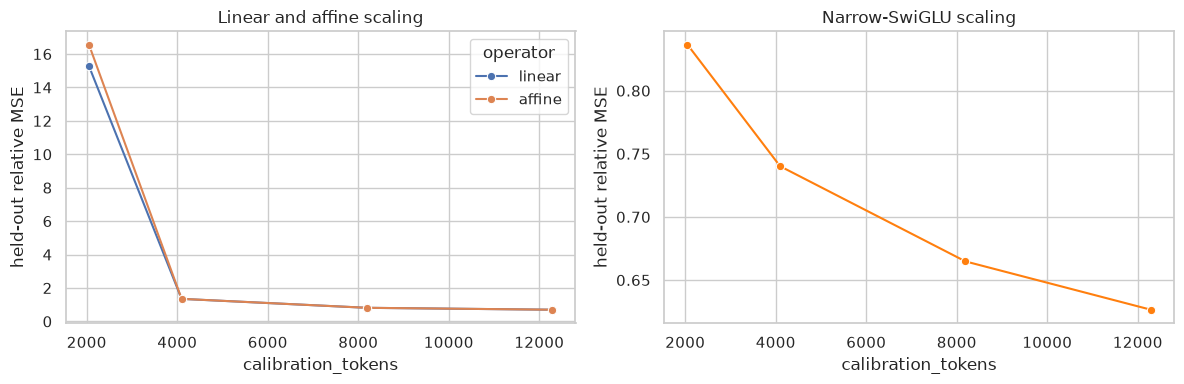

In [18]:
linear_budget_df = budget_df[
    budget_df['operator'].isin(['linear', 'affine'])
]
swiglu_budget_df = budget_df[
    budget_df['operator'] == 'swiglu_0.50'
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=linear_budget_df,
    x='calibration_tokens',
    y='local_relative_mse',
    hue='operator',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=swiglu_budget_df,
    x='calibration_tokens',
    y='local_relative_mse',
    marker='o',
    color='tab:orange',
    ax=axes[1],
)
axes[0].set(
    title='Linear and affine scaling',
    ylabel='held-out relative MSE',
)
axes[1].set(
    title='Narrow-SwiGLU scaling',
    ylabel='held-out relative MSE',
)
plt.tight_layout()

SwiGLU training and validation histories by calibration budget.

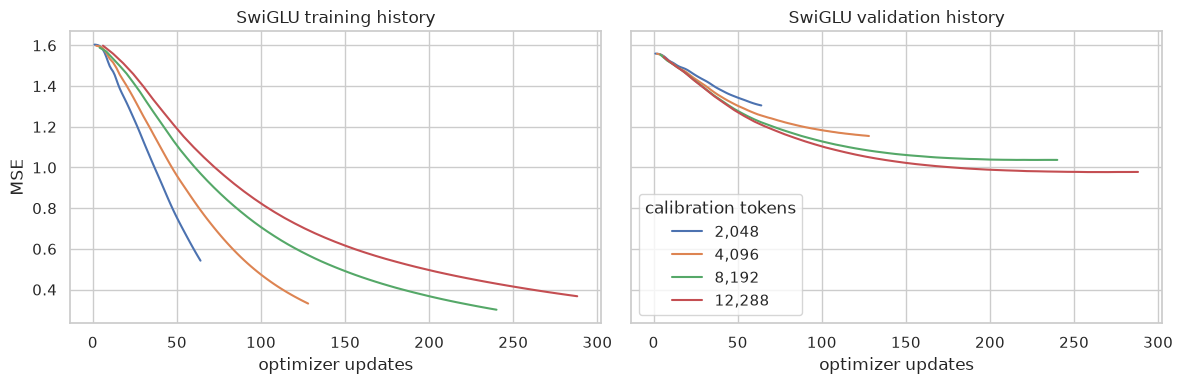

In [19]:
history_plot_df = history_df.copy()
history_plot_df['calibration_budget'] = history_plot_df[
    'calibration_tokens'
].map(lambda value: f'{value:,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=history_plot_df,
    x='optimizer_steps',
    y='train_mse',
    hue='calibration_budget',
    legend=False,
    ax=axes[0],
)
sns.lineplot(
    data=history_plot_df,
    x='optimizer_steps',
    y='validation_mse',
    hue='calibration_budget',
    ax=axes[1],
)
axes[0].set(
    title='SwiGLU training history',
    xlabel='optimizer updates',
    ylabel='MSE',
)
axes[1].set(
    title='SwiGLU validation history',
    xlabel='optimizer updates',
    ylabel='MSE',
)
axes[1].legend(title='calibration tokens')
plt.tight_layout()

Model-wide validation impact by calibration budget.

,operator,calibration_batches,calibration_tokens,loss,delta_loss,perplexity,delta_perplexity
1,affine,8,2048,4.593343,1.923370,98.824280,84.384694
0,linear,8,2048,4.441403,1.771430,84.894001,70.454416
2,swiglu_0.50,8,2048,2.730558,0.060584,15.341441,0.901855
4,affine,16,4096,2.786200,0.116227,16.219277,1.779691
3,linear,16,4096,2.787512,0.117538,16.240557,1.800972
5,swiglu_0.50,16,4096,2.722960,0.052987,15.225325,0.785739
7,affine,32,8192,2.738249,0.068276,15.459895,1.020309
6,linear,32,8192,2.738213,0.068240,15.459340,1.019754
8,swiglu_0.50,32,8192,2.720240,0.050266,15.183963,0.744377
10,affine,48,12288,2.726351,0.056378,15.277043,0.837457


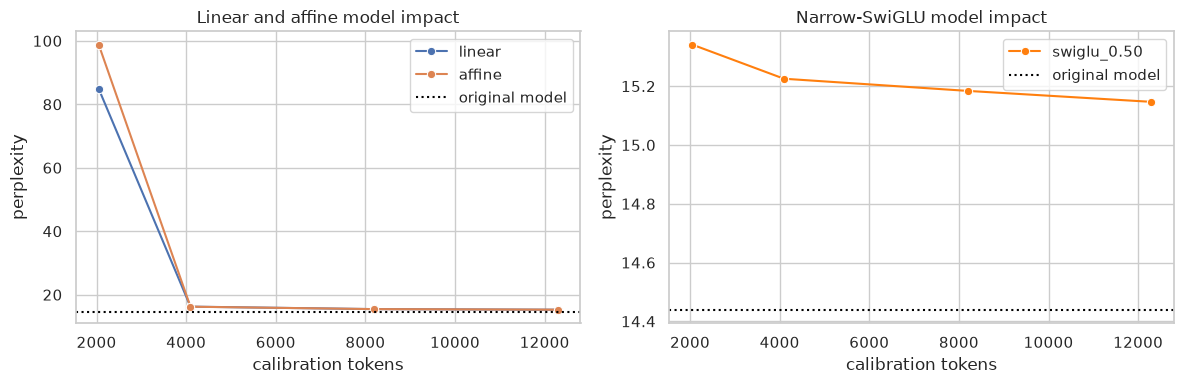

In [20]:
model_budget_df = budget_df[[
    'operator',
    'calibration_batches',
    'calibration_tokens',
    'loss',
    'delta_loss',
    'perplexity',
    'delta_perplexity',
]].sort_values(['calibration_tokens', 'operator'])
display(model_budget_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=linear_budget_df,
    x='calibration_tokens',
    y='perplexity',
    hue='operator',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=swiglu_budget_df,
    x='calibration_tokens',
    y='perplexity',
    marker='o',
    color='tab:orange',
    label='swiglu_0.50',
    ax=axes[1],
)
for axis in axes:
    axis.axhline(
        baseline_lm.perplexity,
        color='black',
        linestyle=':',
        label='original model',
    )
    axis.set(xlabel='calibration tokens', ylabel='perplexity')
    axis.legend()
axes[0].set_title('Linear and affine model impact')
axes[1].set_title('Narrow-SwiGLU model impact')
plt.tight_layout()

#### swiGLU analysis

- Compare reduced-width SwiGLU operators against the maximum-budget linear and affine references using local error and model ppl

,operator,calibration_tokens,parameters,local_mse,local_relative_mse,local_cosine,best_epoch,optimizer_steps,loss,perplexity,delta_loss,delta_perplexity,calibration_batches,width_ratio,intermediate_width,relative_block_parameters
0,swiglu_0.25,12288,12582912,1.009542,0.647126,0.600186,50,318,2.717289,15.139226,0.047316,0.699640,NaN,0.25,2048,0.250000
1,swiglu_0.50,12288,25165824,0.977388,0.626515,0.616383,45,288,2.717785,15.146728,0.047811,0.707142,48.0,0.50,4096,0.500000
2,swiglu_0.75,12288,37748736,0.958872,0.614646,0.625006,41,264,2.719236,15.168725,0.049262,0.729140,NaN,0.75,6144,0.750000
3,swiglu_0.90,12288,45299712,0.951164,0.609705,0.628885,40,258,2.718934,15.164152,0.048961,0.724567,NaN,0.90,7373,0.900024


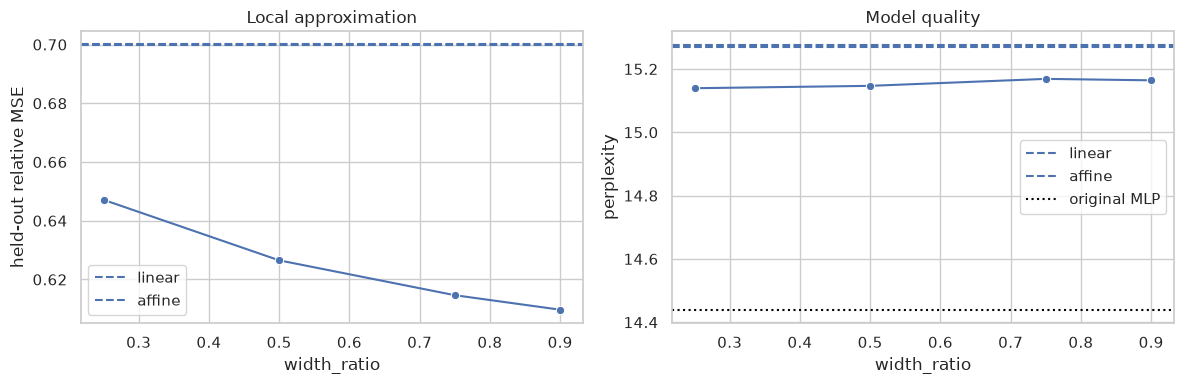

In [21]:
full_pairs = calibration_prefix(MAX_CALIBRATION_BATCHES)
max_budget_df = budget_df[
    budget_df['calibration_batches'] == MAX_CALIBRATION_BATCHES
]
reference_df = max_budget_df[
    max_budget_df['operator'].isin(['linear', 'affine'])
].copy()
reference_rows = reference_df.to_dict(orient='records')

half_width_row = max_budget_df[
    max_budget_df['operator'] == 'swiglu_0.50'
].iloc[0].to_dict()
half_width_row.update({
    'width_ratio': 0.50,
    'intermediate_width': round(
        0.50 * original_intermediate_width
    ),
    'relative_block_parameters': (
        half_width_row['parameters'] / original_parameters
    ),
})
width_rows = [half_width_row]
width_modules = {0.50: swiglu_fit.module}

for ratio in SWIGLU_WIDTH_RATIOS:
    if ratio == 0.50:
        continue
    width = max(1, round(ratio * original_intermediate_width))
    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(hidden_size, width, bias=False),
        full_pairs,
        validation_pairs,
        training_config,
        device,
    )
    row = local_row(f'swiglu_{ratio:.2f}', fit.module, full_pairs, fit)
    integrated = model_metrics(fit.module)
    width_modules[ratio] = fit.module
    row.update({
        'width_ratio': ratio,
        'intermediate_width': width,
        'relative_block_parameters': (
            count_parameters(fit.module) / original_parameters
        ),
        'loss': integrated.loss,
        'delta_loss': integrated.loss - baseline_lm.loss,
        'perplexity': integrated.perplexity,
        'delta_perplexity': (
            integrated.perplexity - baseline_lm.perplexity
        ),
    })
    width_rows.append(row)

width_df = (
    pd.DataFrame(width_rows)
    .sort_values('width_ratio')
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='local_relative_mse',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='perplexity',
    marker='o',
    ax=axes[1],
)
for reference in reference_df.itertuples():
    axes[0].axhline(
        reference.local_relative_mse,
        linestyle='--',
        label=reference.operator,
    )
    axes[1].axhline(
        reference.perplexity,
        linestyle='--',
        label=reference.operator,
    )
axes[1].axhline(
    baseline_lm.perplexity,
    color='black',
    linestyle=':',
    label='original MLP',
)
axes[0].set(title='Local approximation', ylabel='held-out relative MSE')
axes[1].set(title='Model quality', ylabel='perplexity')
for axis in axes:
    axis.legend()
plt.tight_layout()
width_df

#### Recovery across SwiGLU widths

Each width follows one cumulative teacher-logit recovery trajectory. One cached C4 batch equals one optimizer update, and only the replacement operator is trainable.

In [22]:
def recover_width_trajectory(module, width_ratio, teacher_cache):
    pre_recovery = width_df.loc[
        width_df['width_ratio'] == width_ratio
    ].iloc[0]
    rows = [{
        'width_ratio': width_ratio,
        'recovery_updates': 0,
        'recovery_tokens': 0,
        'loss': pre_recovery['loss'],
        'perplexity': pre_recovery['perplexity'],
        'delta_loss': pre_recovery['delta_loss'],
        'delta_perplexity': pre_recovery['delta_perplexity'],
    }]
    checkpoints = set(RECOVERY_UPDATE_BUDGETS[1:])

    with temporary_replacement(model, TARGET_LAYER, module):
        original_flags = [
            (parameter, parameter.requires_grad)
            for parameter in model.parameters()
        ]
        for parameter, _ in original_flags:
            parameter.requires_grad = False
        trainable = tuple(module.parameters())
        for parameter in trainable:
            parameter.requires_grad = True
        optimizer = torch.optim.AdamW(
            trainable,
            lr=recovery_config.learning_rate,
            weight_decay=recovery_config.weight_decay,
        )

        try:
            model.eval()
            module.train()
            for update, batch in enumerate(teacher_cache.batches, start=1):
                loss = distillation_loss(
                    model, batch, recovery_config.temperature, device
                )
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

                if update in checkpoints:
                    metrics = evaluate_language_model(
                        model,
                        loaders.model_validation,
                        device,
                        data_config.num_model_validation_batches,
                    )
                    rows.append({
                        'width_ratio': width_ratio,
                        'recovery_updates': update,
                        'recovery_tokens': (
                            update
                            * data_config.batch_size
                            * data_config.sequence_length
                        ),
                        'loss': metrics.loss,
                        'perplexity': metrics.perplexity,
                        'delta_loss': metrics.loss - baseline_lm.loss,
                        'delta_perplexity': (
                            metrics.perplexity - baseline_lm.perplexity
                        ),
                    })
                    print(
                        f'width={width_ratio:.2f}, '
                        f'updates={update}, ppl={metrics.perplexity:.4f}'
                    )
                    module.train()
            module.eval()
        finally:
            for parameter, requires_grad in original_flags:
                parameter.requires_grad = requires_grad

    return rows

In [23]:
print(f'Caching {max(RECOVERY_UPDATE_BUDGETS)} teacher batches...')
teacher_cache = cache_teacher_logits(
    model,
    loaders.recovery,
    max(RECOVERY_UPDATE_BUDGETS),
    device,
    recovery_config.cache_dtype,
)
print('Teacher cache ready.')

recovery_rows = []
for ratio in SWIGLU_WIDTH_RATIOS:
    torch.manual_seed(SEED)
    recovery_rows.extend(
        recover_width_trajectory(
            width_modules[ratio], ratio, teacher_cache
        )
    )

recovery_df = pd.DataFrame(recovery_rows)
del teacher_cache
recovery_df

Caching 64 teacher batches...
Teacher cache ready.
width=0.25, updates=8, ppl=15.1410
width=0.25, updates=16, ppl=15.1341
width=0.25, updates=32, ppl=15.1456
width=0.25, updates=64, ppl=15.1356
width=0.50, updates=8, ppl=15.1478
width=0.50, updates=16, ppl=15.1452
width=0.50, updates=32, ppl=15.1521
width=0.50, updates=64, ppl=15.1428
width=0.75, updates=8, ppl=15.1748
width=0.75, updates=16, ppl=15.1612
width=0.75, updates=32, ppl=15.1599
width=0.75, updates=64, ppl=15.1408
width=0.90, updates=8, ppl=15.1529
width=0.90, updates=16, ppl=15.1447
width=0.90, updates=32, ppl=15.1364
width=0.90, updates=64, ppl=15.1478


,width_ratio,recovery_updates,recovery_tokens,loss,perplexity,delta_loss,delta_perplexity
0,0.25,0,0,2.717289,15.139226,0.047316,0.699640
1,0.25,8,2048,2.717407,15.141012,0.047434,0.701427
2,0.25,16,4096,2.716951,15.134108,0.046978,0.694522
3,0.25,32,8192,2.717709,15.145591,0.047736,0.706005
4,0.25,64,16384,2.717050,15.135603,0.047076,0.696017
5,0.50,0,0,2.717785,15.146728,0.047811,0.707142
6,0.50,8,2048,2.717853,15.147767,0.047880,0.708182
7,0.50,16,4096,2.717686,15.145240,0.047713,0.705654
8,0.50,32,8192,2.718137,15.152069,0.048164,0.712483
9,0.50,64,16384,2.717524,15.142776,0.047550,0.703190


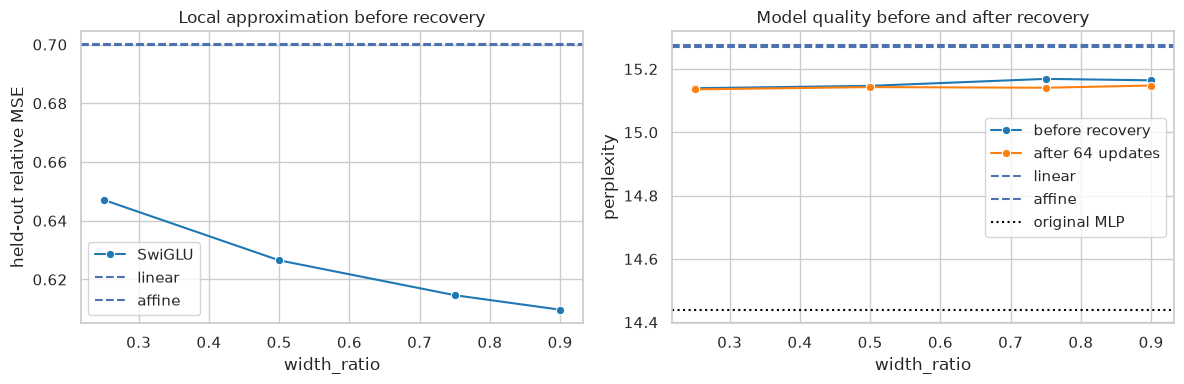

In [24]:
final_recovery_update = max(RECOVERY_UPDATE_BUDGETS)
quality_df = pd.concat([
    width_df[['width_ratio', 'perplexity']].assign(
        recovery='before recovery'
    ),
    recovery_df[
        recovery_df['recovery_updates'] == final_recovery_update
    ][['width_ratio', 'perplexity']].assign(
        recovery=f'after {final_recovery_update} updates'
    ),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='local_relative_mse',
    marker='o',
    color='tab:blue',
    label='SwiGLU',
    ax=axes[0],
)
sns.lineplot(
    data=quality_df,
    x='width_ratio',
    y='perplexity',
    hue='recovery',
    marker='o',
    palette={
        'before recovery': 'tab:blue',
        f'after {final_recovery_update} updates': 'tab:orange',
    },
    ax=axes[1],
)
for reference in reference_df.itertuples():
    axes[0].axhline(
        reference.local_relative_mse,
        linestyle='--',
        label=reference.operator,
    )
    axes[1].axhline(
        reference.perplexity,
        linestyle='--',
        label=reference.operator,
    )
axes[1].axhline(
    baseline_lm.perplexity,
    color='black',
    linestyle=':',
    label='original MLP',
)
axes[0].set(
    title='Local approximation before recovery',
    ylabel='held-out relative MSE',
)
axes[1].set(
    title='Model quality before and after recovery',
    ylabel='perplexity',
)
for axis in axes:
    axis.legend()
plt.tight_layout()

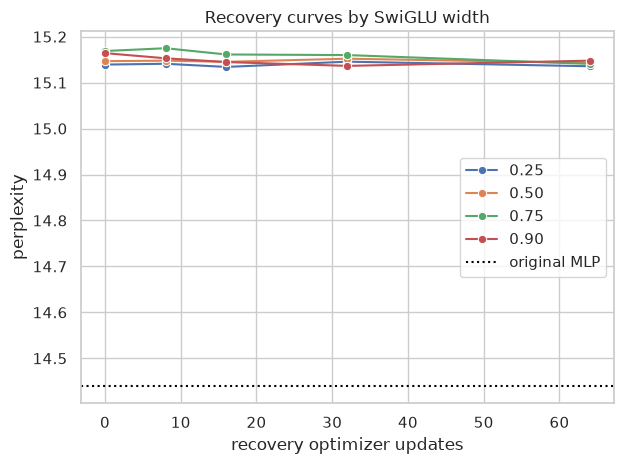

In [25]:
recovery_plot_df = recovery_df.copy()
recovery_plot_df['width'] = recovery_plot_df['width_ratio'].map(
    lambda ratio: f'{ratio:.2f}'
)
ax = sns.lineplot(
    data=recovery_plot_df,
    x='recovery_updates',
    y='perplexity',
    hue='width',
    marker='o',
)
ax.axhline(
    baseline_lm.perplexity,
    color='black',
    linestyle=':',
    label='original MLP',
)
ax.set(
    title='Recovery curves by SwiGLU width',
    xlabel='recovery optimizer updates',
    ylabel='perplexity',
)
ax.legend()
plt.tight_layout()

___

### Block comparison

- comparison of differen block behaviour on baselines (e.g. validation loss across layers=[3, 11, 19])
- maybe 3D surface plots (calibration, retraining) -> ppl, compare block diffs

### Pareto Frontier Baseline

- picking the best baseline in selected trade-off.

___

### Multi-block Experiments